<a href="https://colab.research.google.com/github/HimanshuRa0/Deep-learning/blob/main/EXP_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Experiment 15: RNN Model to Predict Miles Travelled by Vehicles

**Language:** Python  
**Duration:** 1 hour  

## Objective
To create a Recurrent Neural Network (RNN) model and use it to predict miles travelled by vehicles from time-series data.

## What this notebook covers
- create a vehicle-miles time-series dataset
- preprocess and scale the data
- convert it into sequences for RNN input
- build and train a SimpleRNN model
- predict future miles travelled
- compare actual vs predicted values

> This notebook is self-contained and uses a realistic synthetic dataset so it runs without needing an external file.
> If you already have your own CSV, a template is included below to replace the synthetic data section.


In [1]:

# Install only if needed:
# !pip install numpy pandas matplotlib scikit-learn tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

np.random.seed(42)
tf.random.set_seed(42)


## 1. Create / load dataset

In [2]:

# Synthetic vehicle miles travelled dataset
# We simulate 500 days of travel with trend + seasonality + noise

days = 500
date_index = pd.date_range(start="2023-01-01", periods=days, freq="D")

trend = np.linspace(50, 120, days)                         # slow increase in miles over time
seasonality = 12 * np.sin(np.arange(days) * 2 * np.pi / 30)  # monthly-like pattern
weekly_pattern = 5 * np.sin(np.arange(days) * 2 * np.pi / 7) # weekly pattern
noise = np.random.normal(0, 4, days)

miles = trend + seasonality + weekly_pattern + noise
miles = np.maximum(miles, 5)  # keep all values positive

df = pd.DataFrame({
    "Date": date_index,
    "Miles_Travelled": miles
})

df.head()


,Date,Miles_Travelled
0,2023-01-01,51.986857
1,2023-01-02,55.991321
2,2023-01-03,62.626795
3,2023-01-04,65.735803
4,2023-01-05,56.372828


In [3]:

# Uncomment and use this instead if you have your own CSV file
# Expected columns: Date, Miles_Travelled

# df = pd.read_csv("vehicle_miles.csv")
# df["Date"] = pd.to_datetime(df["Date"])
# df = df.sort_values("Date").reset_index(drop=True)
# df.head()


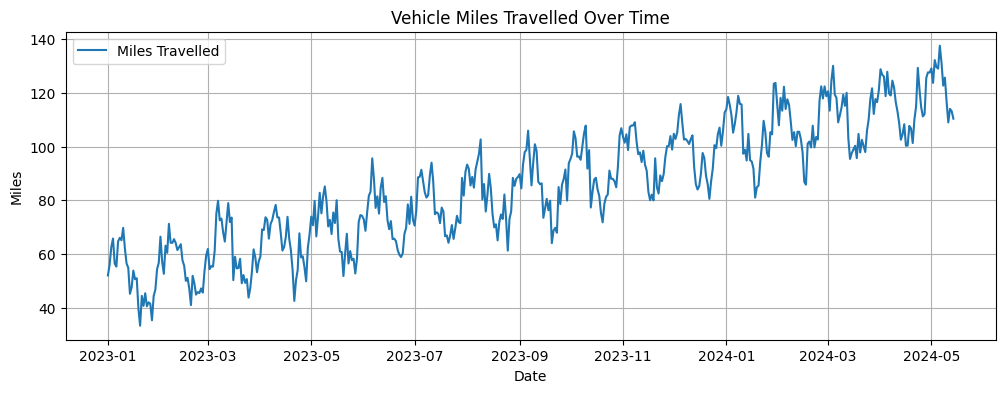

In [4]:

plt.figure(figsize=(12, 4))
plt.plot(df["Date"], df["Miles_Travelled"], label="Miles Travelled")
plt.title("Vehicle Miles Travelled Over Time")
plt.xlabel("Date")
plt.ylabel("Miles")
plt.legend()
plt.grid(True)
plt.show()


## 2. Preprocess data

In [5]:

data = df["Miles_Travelled"].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print("Original shape:", data.shape)
print("Scaled shape:", scaled_data.shape)


Original shape: (500, 1)
Scaled shape: (500, 1)


## 3. Convert time series into supervised learning sequences

In [6]:

def create_sequences(dataset, time_steps=20):
    X, y = [], []
    for i in range(len(dataset) - time_steps):
        X.append(dataset[i:i + time_steps, 0])
        y.append(dataset[i + time_steps, 0])
    return np.array(X), np.array(y)

time_steps = 20
X, y = create_sequences(scaled_data, time_steps)

# reshape for RNN: [samples, time_steps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (480, 20, 1)
y shape: (480,)


## 4. Train-test split

In [7]:

split_index = int(0.8 * len(X))

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 384
Testing samples: 96


## 5. Build the RNN model

In [8]:

model = Sequential([
    SimpleRNN(50, activation="tanh", return_sequences=True, input_shape=(time_steps, 1)),
    Dropout(0.2),
    SimpleRNN(30, activation="tanh"),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 20, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 30)             │         2,430 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,061 (19.77 KB)

 Trainable params: 5,061 (19.77 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the model

In [9]:

history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)


Epoch 1/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.2446 - val_loss: 0.0090
Epoch 2/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0928 - val_loss: 0.0335
Epoch 3/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0610 - val_loss: 0.0165
Epoch 4/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0450 - val_loss: 0.0098
Epoch 5/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0402 - val_loss: 0.0047
Epoch 6/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0269 - val_loss: 0.0070
Epoch 7/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0240 - val_loss: 0.0045
Epoch 8/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0231 - val_loss: 0.0069
Epoch 9/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0140 - val_loss: 0.0039
Epoch 10/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0150 - val_loss: 0.0078
Epoch 11/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0160 - val_loss: 0.0038
Epoch 12/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0

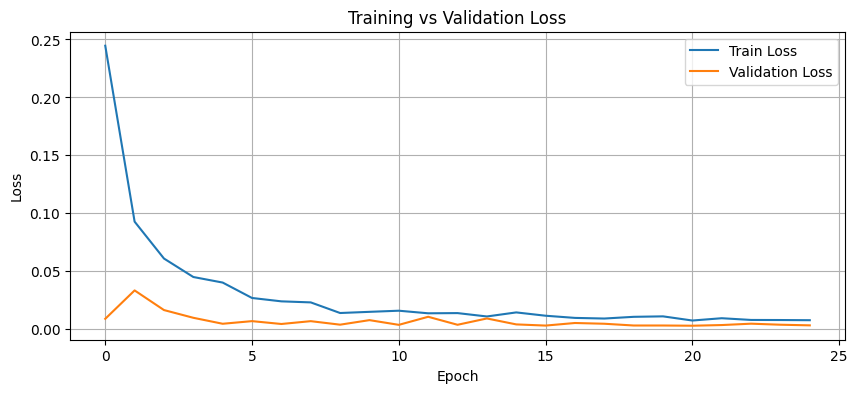

In [10]:

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


## 7. Predict miles travelled

In [11]:

y_pred = model.predict(X_test)

# Convert scaled values back to original scale
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = scaler.inverse_transform(y_pred)

results = pd.DataFrame({
    "Actual_Miles": y_test_actual.flatten(),
    "Predicted_Miles": y_pred_actual.flatten()
})

results.head(10)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 


,Actual_Miles,Predicted_Miles
0,102.493386,102.349258
1,105.395870,102.058159
2,100.188486,103.613121
3,105.552988,106.171875
4,105.536868,102.716599
5,102.684186,101.151855
6,97.799766,96.356613
7,86.869424,95.894760
8,85.815714,91.312622
9,101.112316,95.806808


## 8. Evaluate the model

In [12]:

mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")


MAE  : 4.917
RMSE : 6.018
R²   : 0.703


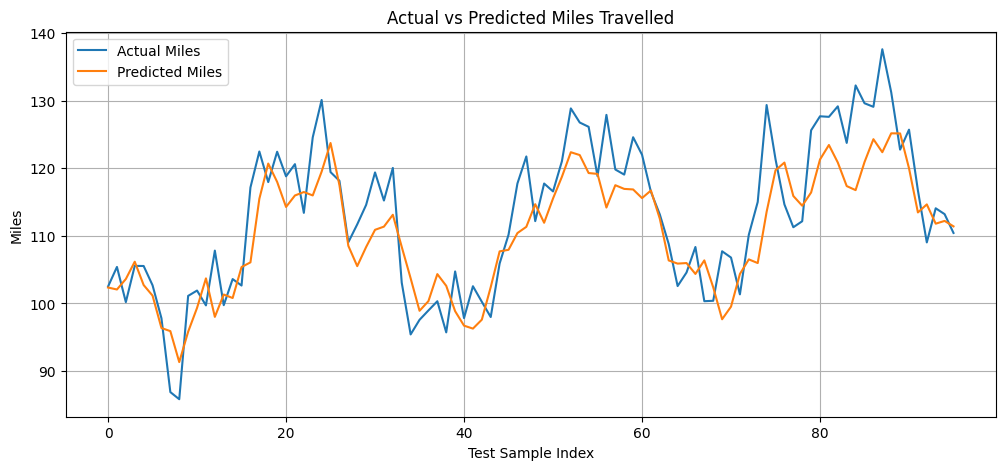

In [13]:

plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label="Actual Miles")
plt.plot(y_pred_actual, label="Predicted Miles")
plt.title("Actual vs Predicted Miles Travelled")
plt.xlabel("Test Sample Index")
plt.ylabel("Miles")
plt.legend()
plt.grid(True)
plt.show()


## 9. Predict next day's miles

In [14]:

last_sequence = scaled_data[-time_steps:].reshape(1, time_steps, 1)
next_day_scaled = model.predict(last_sequence)
next_day_miles = scaler.inverse_transform(next_day_scaled)

print("Predicted miles for next day:", round(float(next_day_miles[0][0]), 2))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
Predicted miles for next day: 107.0



## 10. Conclusion

In this experiment, we built a SimpleRNN model to predict miles travelled by vehicles using time-series data.  
The workflow included:
- preparing vehicle travel data
- scaling and sequence generation
- training the RNN
- evaluating prediction performance
- forecasting future miles travelled

This experiment demonstrates how RNNs can capture temporal patterns in vehicle movement data.
